In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ipywidgets as widgets
import plotly.graph_objects as go

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving laptop2.csv to laptop2 (1).csv


In [ ]:
df = pd.read_csv("/content/laptop2.csv")

EDA

In [ ]:
df.shape

(1303, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1303 non-null   object 
 1   TypeName       1303 non-null   object 
 2   Ram            1303 non-null   int64  
 3   OpSys          1237 non-null   object 
 4   Weight         1303 non-null   float64
 5   Touchscreen    1303 non-null   int64  
 6   CpuCompany     1303 non-null   object 
 7   ClockSpeed     1303 non-null   float64
 8   Flash Storage  1176 non-null   float64
 9   HDD            1201 non-null   float64
 10  Hybrid         1177 non-null   float64
 11  SSD            1303 non-null   float64
 12  GPU            1303 non-null   object 
 13  Ppi            1303 non-null   float64
 14  Price          1303 non-null   float64
dtypes: float64(8), int64(2), object(5)
memory usage: 152.8+ KB


In [ ]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Touchscreen,CpuCompany,ClockSpeed,Flash Storage,HDD,Hybrid,SSD,GPU,Ppi,Price
0,Apple,Ultrabook,8,macOS,1.37,0,Intel,2.3,0.000,0.0,0.0,0.128,Intel,312.781955,71378.6832
1,Apple,Ultrabook,8,macOS,1.34,0,Intel,1.8,0.128,0.0,0.0,0.000,Intel,175.939850,47895.5232
2,HP,Notebook,8,NaN,1.86,0,Intel,2.5,0.000,0.0,0.0,0.256,Intel,192.307692,30636.0000
3,Apple,Ultrabook,16,macOS,1.83,0,Intel,2.7,NaN,0.0,0.0,0.512,AMD,303.896104,135195.3360
4,Apple,Ultrabook,8,macOS,1.37,0,Intel,3.1,0.000,0.0,0.0,0.256,Intel,312.781955,96095.8080


Identifying Numerical and Categorical Columns

In [ ]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns:  {numerical_columns}")
print(f"Categorical columns:  {categorical_columns}")

Numerical columns:  ['Ram', 'Weight', 'Touchscreen', 'ClockSpeed', 'Flash Storage', 'HDD', 'Hybrid', 'SSD', 'Ppi', 'Price']
Categorical columns:  ['Company', 'TypeName', 'OpSys', 'CpuCompany', 'GPU']


In [ ]:
for col in categorical_columns:
    print(col)
    print(df[col].unique())
    print('-----')

Company
['Apple' 'HP' 'Acer' 'Asus' 'Dell' 'Lenovo' 'Chuwi' 'MSI' 'Microsoft'
 'Toshiba' 'Huawei' 'Xiaomi' 'Vero' 'Razer' 'Mediacom' 'Samsung' 'Google'
 'Fujitsu' 'LG']
-----
TypeName
['Ultrabook' 'Notebook' 'Netbook' 'Gaming' '2 in 1 Convertible'
 'Workstation']
-----
OpSys
['macOS' nan 'Windows' 'Mac' 'Linux' 'Android' 'Chrome']
-----
CpuCompany
['Intel' 'AMD' 'Samsung']
-----
GPU
['Intel' 'AMD' 'Nvidia' 'ARM']
-----


In [ ]:
df.isnull().sum()

,0
Company,0
TypeName,0
Ram,0
OpSys,66
Weight,0
Touchscreen,0
CpuCompany,0
ClockSpeed,0
Flash Storage,127
HDD,102


In [ ]:
df.duplicated().sum()

np.int64(21)

Distribution of price

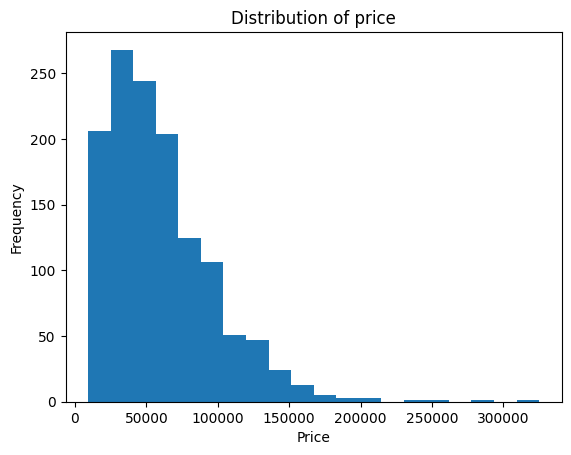

In [ ]:
plt.hist(df['Price'], bins=20)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of price")
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

corr_matrix = df.corr(numeric_only=True)


fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
            aspect="auto"
)

fig.update_layout(
    title="Correlation Heatmap",
    xaxis_title="Features",
    yaxis_title="Features"
)

fig.show()

calculating the correlation between numerical features and the target variable (Price).

In [ ]:
corr_matrix = df[numerical_columns].corr()

corr_matrix['Price'].sort_values(ascending=False)

,Price
Price,1.000000
Ram,0.743007
SSD,0.670799
Ppi,0.472762
ClockSpeed,0.430293
Weight,0.210370
Touchscreen,0.191226
Hybrid,0.019489
Flash Storage,-0.031031
HDD,-0.106697


Detecte outliers

 Outlier Detection Summary
Ram: Found 221 outliers (Lower_bound : -2.00, Upper_bound: 14.00)
Weight: Found 46 outliers (Lower_bound : 0.30, Upper_bound: 3.50)
Touchscreen: Found 192 outliers (Lower_bound : 0.00, Upper_bound: 0.00)
ClockSpeed: Found 4 outliers (Lower_bound : 0.95, Upper_bound: 3.75)
Flash Storage: Found 66 outliers (Lower_bound : 0.00, Upper_bound: 0.00)
HDD: Found 0 outliers (Lower_bound : -1.50, Upper_bound: 2.50)
Hybrid: Found 10 outliers (Lower_bound : 0.00, Upper_bound: 0.00)
SSD: Found 18 outliers (Lower_bound : -0.38, Upper_bound: 0.64)
Ppi: Found 124 outliers (Lower_bound : 112.10, Upper_bound: 275.60)
Price: Found 29 outliers (Lower_bound : -39124.57, Upper_bound: 150313.54)


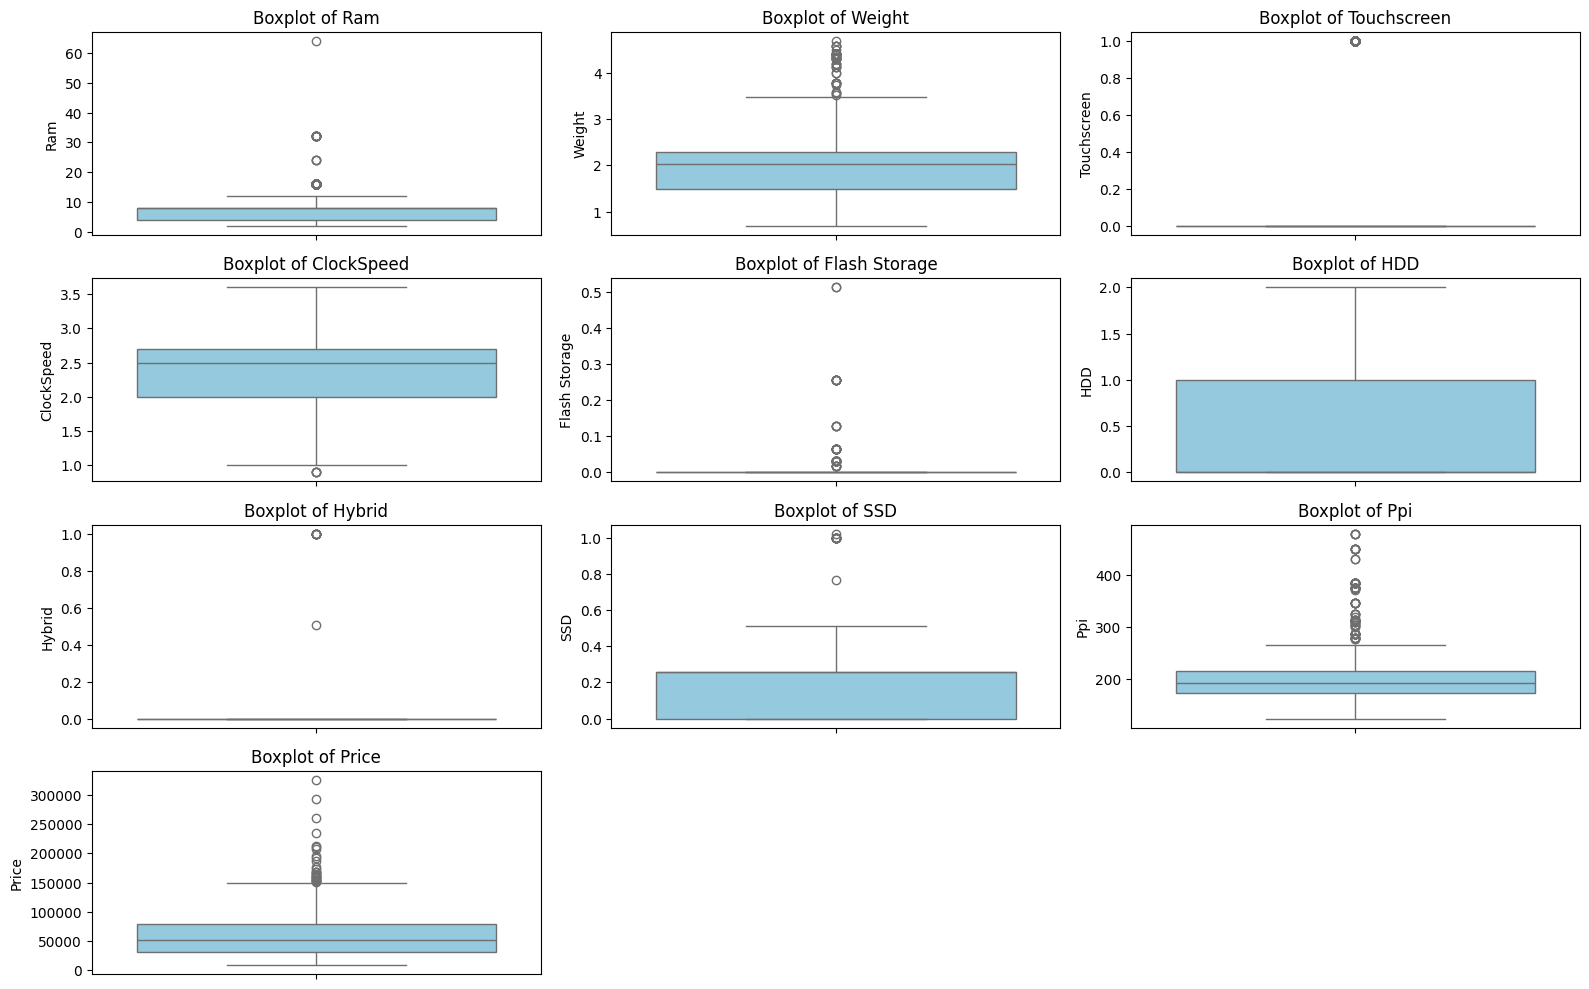

In [ ]:
print(" Outlier Detection Summary")
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: Found {len(outliers)} outliers (Lower_bound : {lower_bound :.2f}, Upper_bound: {upper_bound:.2f})")

plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=df, y=col, color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
def interactive_scatter_with_regression(df, x_col, y_col, title="Scatter Plot with Regression Line"):
    x = df[x_col].values.astype(float)
    y = df[y_col].values.astype(float)
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean) ** 2)
    if denominator == 0:
        slope = 0
    else:
        slope = numerator / denominator
    intercept = y_mean - slope * x_mean
    x_line = np.array([x.min(), x.max()])
    y_line = intercept + slope * x_line
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x,y=y,mode='markers',name='Data Points',marker=dict(size=8, color='skyblue', opacity=0.7)))
    fig.add_trace(go.Scatter(x=x_line,y=y_line,mode='lines',name='Regression Line',line=dict(color='red', width=2, dash='dash'),visible=True))
    equation_text = f"y = {intercept:.4f} + {slope:.4f}·x"
    fig.update_layout(title=title,xaxis_title=x_col,yaxis_title=y_col,template='plotly_white',hovermode='closest',annotations=[dict(x=0.05,y=0.95,xref='paper',yref='paper', text=equation_text,showarrow=False,font=dict(size=12, color='red'),bgcolor='rgba(255,255,255,0.8)')])
    return fig

In [ ]:
#show relation between price & Ram
fig1 = interactive_scatter_with_regression(df, x_col='Ram', y_col='Price',title="Relationship: RAM vs Price")
fig1.show()
#show relation between SSD & price
fig2 = interactive_scatter_with_regression(df, x_col='SSD', y_col='Price',title="Relationship: SSD vs Price")
fig2.show()
#show relation between Ppi  price
fig3 = interactive_scatter_with_regression(df, x_col='Ppi', y_col='Price',title="Relationship: PPI vs Price")
fig3.show()

***Preprocessing***

drop duplicates

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

Train test split

We split the data first to avoid data leakage, so that any preprocessing (like scaling or encoding) is learned only from the training set and then applied to the test set.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

handle outliers

we handle outliers to reduce their effect on the model and improve performance.

In [ ]:
import numpy as np

for col in ['Ram', 'Weight', 'Ppi']:
    upper_limit = X_train[col].quantile(0.90)

    X_train[col] = X_train[col].clip(upper=upper_limit)
    X_test[col] = X_test[col].clip(upper=upper_limit)

lower_limit_clock = X_train['ClockSpeed'].quantile(0.10)
X_train['ClockSpeed'] = X_train['ClockSpeed'].clip(lower=lower_limit_clock)
X_test['ClockSpeed'] = X_test['ClockSpeed'].clip(lower=lower_limit_clock)




Log transformation


This step is used to reduce skewness in the data and make the distribution more normal.

In [ ]:

y_train = np.log1p(y_train)
y_test = np.log1p(y_test)


missing values

In [ ]:
X_train.isnull().sum()

,0
Company,0
TypeName,0
Ram,0
OpSys,58
Weight,0
Touchscreen,0
CpuCompany,0
ClockSpeed,0
Flash Storage,97
HDD,86


In [ ]:
X_test.isnull().sum()

,0
Company,0
TypeName,0
Ram,0
OpSys,8
Weight,0
Touchscreen,0
CpuCompany,0
ClockSpeed,0
Flash Storage,30
HDD,16


Missing values are filled using:
- Mean for numerical columns  
- Mode for categorical columns  

The values are computed from the training set and then applied to both training and test sets .

In [ ]:
cat_cols = X_train.select_dtypes(include=['object']).columns
for col in cat_cols:
    X_train[col] = X_train[col].fillna(X_train[col].mode()[0])
    X_test[col] = X_test[col].fillna(X_train[col].mode()[0])

In [ ]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    X_train[col] = X_train[col].fillna(X_train[col].mean())
    X_test[col] = X_test[col].fillna(X_train[col].mean())

In [ ]:
X_train.isnull().sum()

,0
Company,0
TypeName,0
Ram,0
OpSys,0
Weight,0
Touchscreen,0
CpuCompany,0
ClockSpeed,0
Flash Storage,0
HDD,0


In [ ]:
X_test.isnull().sum()

,0
Company,0
TypeName,0
Ram,0
OpSys,0
Weight,0
Touchscreen,0
CpuCompany,0
ClockSpeed,0
Flash Storage,0
HDD,0


One-Hot Encoding

Categorical columns are converted into binary columns to make them suitable for machine learning models.

This prevents the model from assuming any order between categories.

In [ ]:

X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1025, 47)
X_test shape: (257, 47)


Standard Scalar

This step scales numerical features to have a mean of 0 and a standard deviation of 1.

In [ ]:
train_mean = X_train[num_cols].mean()
train_std = X_train[num_cols].std()
train_std[train_std == 0] = 1

X_train[num_cols] = (X_train[num_cols] - train_mean) / train_std
X_test[num_cols] = (X_test[num_cols] - train_mean) / train_std

X_train_final = X_train
X_test_final = X_test

print(f"Final Train shape: {X_train_final.shape}")

Final Train shape: (1025, 47)


# Choosing the features

In [ ]:
X_test_final.columns
X_train_final.columns

Index(['Ram', 'Weight', 'Touchscreen', 'ClockSpeed', 'Flash Storage', 'HDD',
       'Hybrid', 'SSD', 'Ppi', 'Company_Acer', 'Company_Apple', 'Company_Asus',
       'Company_Chuwi', 'Company_Dell', 'Company_Fujitsu', 'Company_Google',
       'Company_HP', 'Company_Huawei', 'Company_LG', 'Company_Lenovo',
       'Company_MSI', 'Company_Mediacom', 'Company_Microsoft', 'Company_Razer',
       'Company_Samsung', 'Company_Toshiba', 'Company_Vero', 'Company_Xiaomi',
       'TypeName_2 in 1 Convertible', 'TypeName_Gaming', 'TypeName_Netbook',
       'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation',
       'OpSys_Android', 'OpSys_Chrome', 'OpSys_Linux', 'OpSys_Mac',
       'OpSys_Windows', 'OpSys_macOS', 'CpuCompany_AMD', 'CpuCompany_Intel',
       'CpuCompany_Samsung', 'GPU_AMD', 'GPU_ARM', 'GPU_Intel', 'GPU_Nvidia'],
      dtype='object')

In [ ]:
X_train_all = X_train_final.copy()
X_test_all  = X_test_final.copy()

corr = X_train_all.corrwith(pd.Series(y_train)).abs()

best_feature = corr.idxmax()
top5 = corr.sort_values(ascending=False).index[:5]
print("TOP5:",top5)

X_train_best = X_train_all[[best_feature]].values
X_test_best  = X_test_all[[best_feature]].values


X_train_full = X_train_all
X_test_full  = X_test_all

TOP5: Index(['Ram', 'SSD', 'TypeName_Notebook', 'Ppi', 'ClockSpeed'], dtype='object')


In [ ]:
print(X_train_full.dtypes)

Ram                            float64
Weight                         float64
Touchscreen                    float64
ClockSpeed                     float64
Flash Storage                  float64
HDD                            float64
Hybrid                         float64
SSD                            float64
Ppi                            float64
Company_Acer                      bool
Company_Apple                     bool
Company_Asus                      bool
Company_Chuwi                     bool
Company_Dell                      bool
Company_Fujitsu                   bool
Company_Google                    bool
Company_HP                        bool
Company_Huawei                    bool
Company_LG                        bool
Company_Lenovo                    bool
Company_MSI                       bool
Company_Mediacom                  bool
Company_Microsoft                 bool
Company_Razer                     bool
Company_Samsung                   bool
Company_Toshiba          

In [ ]:
X_train_full = X_train_all.copy()
X_test_full  = X_test_all.copy()

X_train_full, X_test_full = X_train_full.align(X_test_full, join='left', axis=1, fill_value=0)

X_train_full = X_train_full.astype(float)
X_test_full  = X_test_full.astype(float)

y_train = y_train.astype(float)
y_test  = y_test.astype(float)

In [ ]:
print(X_train_full.dtypes)

Ram                            float64
Weight                         float64
Touchscreen                    float64
ClockSpeed                     float64
Flash Storage                  float64
HDD                            float64
Hybrid                         float64
SSD                            float64
Ppi                            float64
Company_Acer                   float64
Company_Apple                  float64
Company_Asus                   float64
Company_Chuwi                  float64
Company_Dell                   float64
Company_Fujitsu                float64
Company_Google                 float64
Company_HP                     float64
Company_Huawei                 float64
Company_LG                     float64
Company_Lenovo                 float64
Company_MSI                    float64
Company_Mediacom               float64
Company_Microsoft              float64
Company_Razer                  float64
Company_Samsung                float64
Company_Toshiba          

In [ ]:
features = ['Ram','SSD','Ppi','Company_Apple','Company_HP','TypeName_Gaming','GPU_Nvidia','CpuCompany_Intel']
X_test_final = X_test_final[features].values
X_train_final = X_train_final[features].values


#Building the Models

**1- Simple Linear Regression Statistical View**

 **Role :** Solves regression using direct statistical formulas.

In [ ]:
class SimpleLinearRegressionStatistical:
    def __init__(self, lasso=0, ridge=0):
        self.B_0 = None
        self.B_1 = None
        self.MSE = None
        self.lasso = lasso  # lambda for L1
        self.ridge = ridge  # lambda for L2

    def hypothesis(self, X):
        return self.B_0 + self.B_1 * X

    def cost_function(self, y_true, y_pred):
        n = len(y_true)
        SSE = np.sum((y_pred - y_true)**2)
        ridge_term = self.ridge * (self.B_1**2)
        lasso_term = self.lasso * abs(self.B_1)
        return SSE/(n-2) + ridge_term + lasso_term

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n = len(X)
        x_bar = X.mean()
        y_bar = y.mean()
        SXX = np.sum(X**2) - (n * (x_bar**2))
        SXY = np.sum(X * y) - (n * x_bar * y_bar)
        self.B_1 = SXY / SXX
        self.B_0 = y_bar - self.B_1 * x_bar
        y_pred = self.hypothesis(X)
        self.MSE = self.cost_function(y, y_pred)
        print(f"Statistical View Results:")
        print(f"  B_0 (intercept) = {self.B_0:.6f}")
        print(f"  B_1 (slope)     = {self.B_1:.6f}")
        print(f"  MSE             = {self.MSE:.6f}")
        print(f"  Lasso (lambda)  = {self.lasso}")
        print(f"  Ridge (lambda)  = {self.ridge}")
        return self

    def predict(self, X):
        return self.hypothesis(X)

    def r2_score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - (ss_res / ss_tot)

    def adjusted_r2_score(self, X, y):
        r2 = self.r2_score(X, y)
        n = len(y)
        k = 1 # For simple linear regression, k is always 1
        if n - k - 1 <= 0:
            return float('nan') # Avoid division by zero or non-positive denominator
        adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
        return adj_r2

    def plot_regression_line(self, X, y):
        X = np.array(X)
        y = np.array(y)
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='blue', alpha=0.6, label='Data points')
        X_line = np.linspace(X.min(), X.max(), 100)
        y_line = self.predict(X_line)
        plt.plot(X_line, y_line, color='red', linewidth=2, label='Regression line')
        plt.xlabel('X')
        plt.ylabel('y')
        plt.title(f'Statistical View: y = {self.B_0:.4f} + {self.B_1:.4f}x | Lasso={self.lasso} Ridge={self.ridge}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def plot_residuals(self, X, y):
        X = np.array(X)
        y = np.array(y)
        y_pred = self.predict(X)
        residuals = y - y_pred
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.scatter(y_pred, residuals, alpha=0.6, color='blue', edgecolors='black')
        plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
        plt.xlabel('Predicted Values')
        plt.ylabel('Residuals')
        plt.title('Residuals vs Predicted')
        plt.grid(True, alpha=0.3)
        plt.subplot(1, 2, 2)
        plt.hist(residuals, bins=20, color='blue', edgecolor='black', alpha=0.7)
        plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
        plt.xlabel('Residuals')
        plt.ylabel('Frequency')
        plt.title('Residuals Distribution')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_predictions_vs_true(self, X, y):
        X = np.array(X).flatten()
        y = np.array(y).flatten()
        y_pred = self.predict(X)
        plt.figure(figsize=(8, 6))
        plt.scatter(y, y_pred, alpha=0.5, color='blue', edgecolors='black')
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect Prediction')
        plt.xlabel('True Values')
        plt.ylabel('Predictions')
        plt.title(f'Statistical View: Predictions vs True (R²= {self.r2_score(X, y):.4f})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

**Explaination of every function :**

*   init() --> intitialize B_0 (intercept), B_1 (slope), and MSE to None.

*   hypothesis() --> predection formula: y = B_0 + B_1 * X

*   cost_function(y_true,y_pred) --> calculates MSE = (1/n-2)* sum(y_pred - y_true)**2

*   fit(x,y) --> computes B_1 = Sxy/Sxx and B_0 = y_bar - B_1 * x_bar using statistical formulas

*   predict(x) --> returns predicted values using the fitted model

*   r2_score(x,y) --> calculates r_squared to measure how well the model fits the data

*   plot_regression_line(x,y) --> scatter plot of data + fitted regression line

*   plot_residuals(x,y) --> shows residuals vs predicted values + residual histogram


**2- Simple Linear Regression Numerical View**

**Role :** solves regression by constructing and solving normal equations step by step

In [ ]:
class SimpleLinearRegressionNumerical:
    def __init__(self, lasso=0, ridge=0):
        self.B_0 = None
        self.B_1 = None
        self.MSE = None
        self.lasso = lasso
        self.ridge = ridge

    def hypothesis(self, X):
        return self.B_0 + self.B_1 * X

    def cost_function(self, y_true, y_pred):
        n = len(y_true)
        SSE = np.sum((y_pred - y_true)**2)
        ridge_term = self.ridge * (self.B_1**2)
        lasso_term = self.lasso * abs(self.B_1)
        return SSE/(n-2) + ridge_term + lasso_term

    def fit(self, X, y, show_steps=True):
        X = np.array(X)
        y = np.array(y)
        n = len(X)
        Sx  = np.sum(X)
        Sy  = np.sum(y)
        Sxx = np.sum(X**2)
        Sxy = np.sum(X * y)

        if show_steps:
            print("\nNumerical View - Step by Step:")
            print(f"Step 1: Calculate summations")
            print(f"  n            = {n}")
            print(f"  Sum x        = {Sx:.4f}")
            print(f"  Sum y        = {Sy:.4f}")
            print(f"  Sum x²       = {Sxx:.4f}")
            print(f"  Sum xy       = {Sxy:.4f}")
            print(f"\nStep 2: Form normal equations")
            print(f"  Eq1: {Sy:.4f} = {n} B_0 + {Sx:.4f} B_1")
            print(f"  Eq2: {Sxy:.4f} = {Sx:.4f} B_0 + {Sxx:.4f} B_1")
            print(f"\nStep 3: Solve the system")

        A = np.array([[n, Sx], [Sx, Sxx]])
        b = np.array([Sy, Sxy])
        solution = np.linalg.solve(A, b)
        self.B_0 = solution[0]
        self.B_1 = solution[1]

        if show_steps:
            print(f"  B_0 = {self.B_0:.6f}")
            print(f"  B_1 = {self.B_1:.6f}")

        y_pred = self.hypothesis(X)
        self.MSE = self.cost_function(y, y_pred)
        print(f"\nFinal Model: y = {self.B_0:.6f} + {self.B_1:.6f}x")
        print(f"MSE (with regularization) = {self.MSE:.6f}")
        print(f"Lasso (lambda) = {self.lasso} | Ridge (lambda) = {self.ridge}")
        return self

    def predict(self, X):
        return self.hypothesis(X)

    def r2_score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - (ss_res / ss_tot)

    def adjusted_r2_score(self, X, y):
        r2 = self.r2_score(X, y)
        n = len(y)
        k = 1  # For simple linear regression, k is always 1
        if n - k - 1 <= 0:
            return float('nan')  # Avoid division by zero or non-positive denominator
        adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
        return adj_r2

    def plot_regression_line(self, X, y):
        X = np.array(X)
        y = np.array(y)
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='yellow', alpha=0.6, label='Data points')
        X_line = np.linspace(X.min(), X.max(), 100)
        y_line = self.predict(X_line)
        plt.plot(X_line, y_line, color='purple', linewidth=2, label='Regression line')
        plt.xlabel('X')
        plt.ylabel('y')
        plt.title(f'Numerical View: y = {self.B_0:.4f} + {self.B_1:.4f}x | Lasso={self.lasso} Ridge={self.ridge}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def plot_residuals(self, X, y):
        X = np.array(X)
        y = np.array(y)
        y_pred = self.predict(X)
        residuals = y - y_pred
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.scatter(y_pred, residuals, alpha=0.6, color='yellow', edgecolors='black')
        plt.axhline(y=0, color='orange', linestyle='--', linewidth=2)
        plt.xlabel('Predicted Values')
        plt.ylabel('Residuals')
        plt.title('Residuals vs Predicted')
        plt.grid(True, alpha=0.3)
        plt.subplot(1, 2, 2)
        plt.hist(residuals, bins=20, color='blue', edgecolor='black', alpha=0.7)
        plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
        plt.xlabel('Residuals')
        plt.ylabel('Frequency')
        plt.title('Residuals Distribution')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_predictions_vs_true(self, X, y):
        X = np.array(X).flatten()
        y = np.array(y).flatten()
        y_pred = self.predict(X)
        plt.figure(figsize=(8, 6))
        plt.scatter(y, y_pred, alpha=0.5, color='green', edgecolors='black')
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect Prediction')
        plt.xlabel('True Values')
        plt.ylabel('Predictions')
        plt.title(f'Numerical View: Predictions vs True (R²= {self.r2_score(X, y):.4f})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

**Functions Explanation :**

*   init() --> Initializes B_0, B_1, and MSE to None.

*   hypothesis(X) --> Prediction formula: y_pred = B_0 + B_1 * X

*   cost_function(y_true, y_pred) --> Calculates MSE = (1/n-2) * sum(y_pred - y_true)**2

*   fit(X, y, show_steps) --> Builds normal equations from summations (sum_x, sum_y, sum_x_squared, sum_xy) and solves using linear algebra.

*   predict(X) --> Returns predicted values

*    r2_score(x,y) --> calculates r_squared to measure how well the model fits the data

*   plot_regression_line(X, y) --> Visualizes data points and the fitted line

*   plot_residuals(X, y) --> Residual analysis plot

**3. Multiple Linear Regression with GD :**

**Role:** Solves multi-linear regression using iterative Gradient Descent optimization.


In [ ]:
class MultiLinearRegressionGD:
    def __init__(self, lasso=0, ridge=0):
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.lasso = lasso  # lambda L1
        self.ridge = ridge  # lambda L2

    def hypothesis(self, X):
        return X @ self.weights + self.bias

    def cost_function(self, y_true, y_pred):
        m = len(y_true)
        SSE = (1/(2*m)) * np.sum((y_pred - y_true)**2)
        # L2 Ridge: lambda * sum(w²)
        ridge_term = self.ridge * np.sum(self.weights**2)
        # L1 Lasso: lambda * sum(|w|)
        lasso_term = self.lasso * np.sum(np.abs(self.weights))
        return SSE + ridge_term + lasso_term

    def fit(self, X, y, learning_rate=0.01, epochs=1000, tol=1e-6, verbose=True):
        X = np.array(X)
        y = np.array(y)
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        self.loss_history = []

        if verbose:
            print("\nML View (Gradient Descent):")
            print(f"  Features:       {n}")
            print(f"  Samples:        {m}")
            print(f"  Learning rate:  {learning_rate}")
            print(f"  Max epochs:     {epochs}")
            print(f"  Lasso lambda:   {self.lasso}")
            print(f"  Ridge lambda:   {self.ridge}")

        for epoch in range(epochs):
            y_pred = self.hypothesis(X)

            dw = (1/m) * (X.T @ (y_pred - y))

            dw += 2 * self.ridge * self.weights

            dw += self.lasso * np.sign(self.weights)

            db = (1/m) * np.sum(y_pred - y)

            self.weights -= learning_rate * dw
            self.bias    -= learning_rate * db

            loss = self.cost_function(y, y_pred)
            self.loss_history.append(loss)

            if epoch > 0 and abs(self.loss_history[-2] - loss) < tol:
                if verbose:
                    print(f"\n  Converged at epoch {epoch}")
                break

            if verbose and epoch % 200 == 0 and epoch > 0:
                print(f"  Epoch {epoch}: Loss = {loss:.6f}")

        if verbose:
            print(f"\nFinal Model:")
            print(f"  Bias = {self.bias:.6f}")
            for i, w in enumerate(self.weights):
                print(f"  Weight_{i} = {w:.6f}")
            print(f"  Final Loss = {self.loss_history[-1]:.6f}")
        return self

    def predict(self, X):
        X = np.array(X)
        return self.hypothesis(X)

    def r2_score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - (ss_res / ss_tot)

    def adjusted_r2_score(self, X, y):
        r2 = self.r2_score(X, y)
        n = len(y)
        k = X.shape[1] if len(X.shape) > 1 else 1
        adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
        return adj_r2

    def plot_loss_interactive(self):
        if not self.loss_history:
            print("No loss history available. Train the model first.")
            return None
        epochs = list(range(len(self.loss_history)))
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=epochs,y=self.loss_history,mode='lines',name='Loss',line=dict(color='blue', width=1.5)))
        fig.add_trace(go.Scatter(x=[0],y=[self.loss_history[0]],mode='markers',name=f'Start Loss: {self.loss_history[0]:.6f}',marker=dict(color='green', size=8, symbol='circle')))
        fig.add_trace(go.Scatter(x=[len(self.loss_history)-1],y=[self.loss_history[-1]],mode='markers',name=f'Final Loss: {self.loss_history[-1]:.6f}',marker=dict(color='red', size=8, symbol='circle')))
        fig.update_layout(title=f'Loss vs Iterations (Gradient Descent)<br>Final Loss: {self.loss_history[-1]:.6f}',xaxis_title='Epoch',yaxis_title='Loss',template='plotly_white',hovermode='x unified')
        fig.add_hline(y=self.loss_history[-1], line_dash="dash", line_color="gray",annotation_text=f"Final Loss: {self.loss_history[-1]:.6f}")
        return fig

    def plot_residuals(self, X, y):
        X = np.array(X)
        y = np.array(y)
        y_pred = self.predict(X)
        residuals = y - y_pred
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.scatter(y_pred, residuals, alpha=0.6, color='blue', edgecolors='black')
        plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
        plt.xlabel('Predicted Values')
        plt.ylabel('Residuals')
        plt.title('Residuals vs Predicted')
        plt.grid(True, alpha=0.3)
        plt.subplot(1, 2, 2)
        plt.hist(residuals, bins=20, color='blue', edgecolor='black', alpha=0.7)
        plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
        plt.xlabel('Residuals')
        plt.ylabel('Frequency')
        plt.title('Residuals Distribution')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_predictions_vs_true(self, X, y):
        X = np.array(X)
        y = np.array(y).flatten()
        y_pred = self.predict(X)
        plt.figure(figsize=(8, 6))
        plt.scatter(y, y_pred, alpha=0.5, color='purple', edgecolors='black')
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect Prediction')
        plt.xlabel('True Values')
        plt.ylabel('Predictions')
        plt.title(f'ML View: Predictions vs True (R²= {self.r2_score(X, y):.4f})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

**Function Explanation :**

*   init() --> Initializes weights, bias, and loss history list

*   hypothesis(X) --> Prediction formula: y = X w + b (matrix form)

*   cost_function(y_true, y_pred) --> Calculates MSE = (1/2m) * sum(y_pred - y_true)**2

*   fit(X, y, lr, epochs, tol) --> Iteratively updates weights using gradients: w = w - lr * dw, b = b - lr * db

*   predict(X) --> Returns predictions for new inputs

*   r2_score(x,y) --> calculates r_squared to measure how well the model fits the data

*   plot_loss() --> Shows loss decreasing over epochs (learning curve)

*  plot_residuals(X, y) --> Residuals vs predicted values + distribution

In [ ]:
def plot_model_scatter(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_true = y_test.values.flatten() if hasattr(y_test, 'values') else y_test.flatten()
    y_pred = y_pred.flatten()
    n = len(y_true)
    y_true_mean = np.mean(y_true)
    y_pred_mean = np.mean(y_pred)
    numerator = np.sum((y_true - y_true_mean) * (y_pred - y_pred_mean))
    denominator = np.sum((y_true - y_true_mean) ** 2)
    slope = numerator / denominator if denominator != 0 else 0
    intercept = y_pred_mean - slope * y_true_mean
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true_mean) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    x_line = np.array([y_true.min(), y_true.max()])
    y_line = intercept + slope * x_line
    perfect_line = np.array([y_true.min(), y_true.max()])
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=y_true,y=y_pred,mode='markers',name='Predictions',marker=dict(size=8, color='skyblue', opacity=0.7),hovertemplate='True: %{x:.3f}<br>Predicted: %{y:.3f}<extra></extra>'))
    fig.add_trace(go.Scatter(x=x_line,y=y_line,mode='lines',name='Regression Line',line=dict(color='red', width=2, dash='dash')))
    fig.add_trace(go.Scatter(x=perfect_line,y=perfect_line,mode='lines',name='Perfect Prediction (y=x)',line=dict(color='green', width=2, dash='dot')))
    fig.update_layout(title=f"{model_name}<br>R² = {r2:.4f} | Pred = {intercept:.4f} + {slope:.4f} × True",xaxis_title="True Values",yaxis_title="Predicted Values",template='plotly_white',width=700,height=500)
    return fig

# Testing the models on our data

Testing Models :

1. Statistical View ...

--- Training Model ---
Statistical View Results:
  B_0 (intercept) = 10.801755
  B_1 (slope)     = 0.459060
  MSE             = 0.186332
  Lasso (lambda)  = 0
  Ridge (lambda)  = 0

--- Coefficients ---
  B_0 (Intercept) = 10.801755
  B_1 (Slope) = 0.459060

--- R Squared Scores ---
  Train R Squared: 0.530973
  Test R Squared:  0.470750

--- MSE ---
  MSE: 0.186332

--- Residuals Plot ---


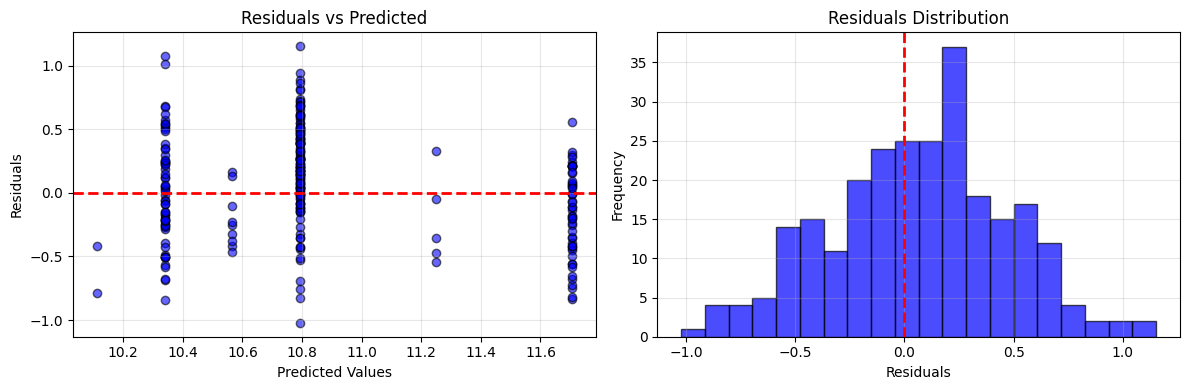


--- Regression Line Plot ---


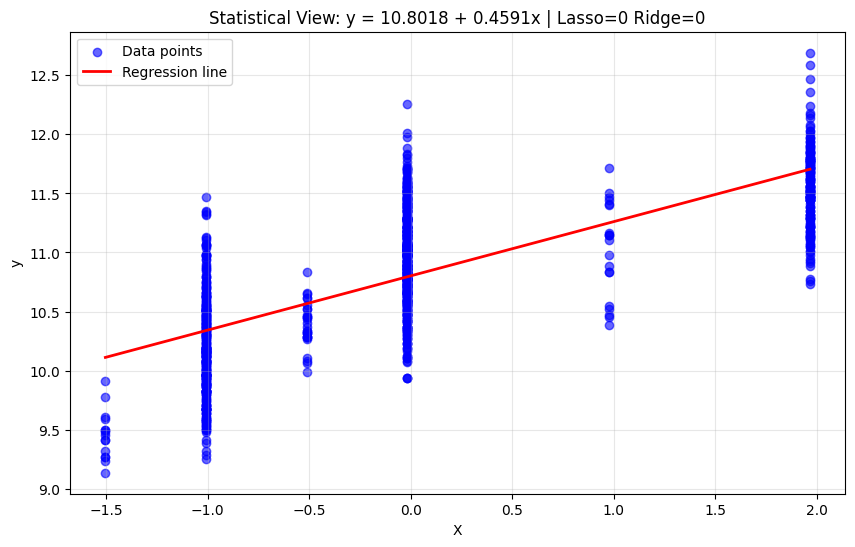

In [ ]:
print("Testing Models :")
print("\n1. Statistical View ...")
stat_model = SimpleLinearRegressionStatistical()
print("\n--- Training Model ---")
stat_model.fit(X_train_final[:, 0], y_train)
print("\n--- Coefficients ---")
print(f"  B_0 (Intercept) = {stat_model.B_0:.6f}")
print(f"  B_1 (Slope) = {stat_model.B_1:.6f}")
y_pred_stat_train = stat_model.predict(X_train_final[:, 0])
y_pred_stat_test = stat_model.predict(X_test_final[:, 0])
print("\n--- R Squared Scores ---")
r2_train_stat = stat_model.r2_score(X_train_final[:, 0], y_train)
r2_test_stat = stat_model.r2_score(X_test_final[:, 0], y_test)
print(f"  Train R Squared: {r2_train_stat:.6f}")
print(f"  Test R Squared:  {r2_test_stat:.6f}")
print("\n--- MSE ---")
print(f"  MSE: {stat_model.MSE:.6f}")
print("\n--- Residuals Plot ---")
stat_model.plot_residuals(X_test_final[:, 0], y_test)
print("\n--- Regression Line Plot ---")
stat_model.plot_regression_line(X_train_final[:, 0], y_train)

In [ ]:
fig_stat = plot_model_scatter(stat_model, X_test_final[:, 0].reshape(-1,1), y_test, "Statistical Linear Regression")
fig_stat.show()

2. Numerical View :

--- Training Model (with steps) ---

Numerical View - Step by Step:
Step 1: Calculate summations
  n            = 1025
  Sum x        = -0.0000
  Sum y        = 11071.7992
  Sum x²       = 1024.0000
  Sum xy       = 470.0771

Step 2: Form normal equations
  Eq1: 11071.7992 = 1025 B_0 + -0.0000 B_1
  Eq2: 470.0771 = -0.0000 B_0 + 1024.0000 B_1

Step 3: Solve the system
  B_0 = 10.801755
  B_1 = 0.459060

Final Model: y = 10.801755 + 0.459060x
MSE (with regularization) = 0.186332
Lasso (lambda) = 0 | Ridge (lambda) = 0

--- Coefficients ---
  B_0 (Intercept) = 10.801755
  B_1 (Slope) = 0.459060

--- R Squared Scores ---
  Train R Squared: 0.530973
  Test R Squared:  0.470750

--- MSE ---
  MSE: 0.186332

--- Residuals Plot ---


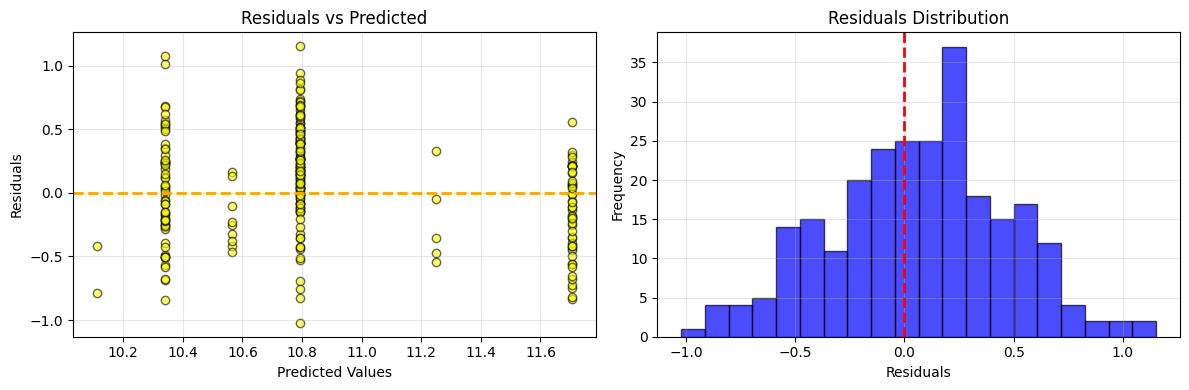


--- Regression Line Plot ---


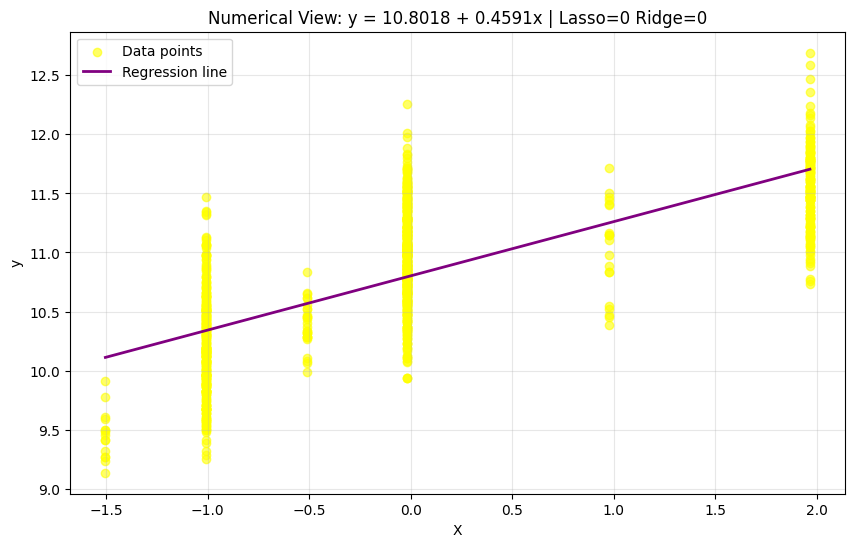

In [ ]:
print("2. Numerical View :")
num_model = SimpleLinearRegressionNumerical()
print("\n--- Training Model (with steps) ---")
num_model.fit(X_train_final[:, 0], y_train, show_steps=True)
print("\n--- Coefficients ---")
print(f"  B_0 (Intercept) = {num_model.B_0:.6f}")
print(f"  B_1 (Slope) = {num_model.B_1:.6f}")
y_pred_num_train = num_model.predict(X_train_final[:, 0])
y_pred_num_test = num_model.predict(X_test_final[:, 0])
print("\n--- R Squared Scores ---")
r2_train_num = num_model.r2_score(X_train_final[:, 0], y_train)
r2_test_num = num_model.r2_score(X_test_final[:, 0], y_test)
print(f"  Train R Squared: {r2_train_num:.6f}")
print(f"  Test R Squared:  {r2_test_num:.6f}")
print("\n--- MSE ---")
print(f"  MSE: {num_model.MSE:.6f}")
print("\n--- Residuals Plot ---")
num_model.plot_residuals(X_test_final[:, 0], y_test)
print("\n--- Regression Line Plot ---")
num_model.plot_regression_line(X_train_final[:, 0], y_train)

In [ ]:
fig_num = plot_model_scatter(num_model, X_test_final[:, 0].reshape(-1,1), y_test, "Numerical Linear Regression")
fig_num.show()

In [ ]:
print("Data types before conversion:")
print(f"X_train_final dtype: {X_train_final.dtypes.iloc[0] if hasattr(X_train_final, 'dtypes') else type(X_train_final[0])}")
print(f"y_train dtype: {y_train.dtype if hasattr(y_train, 'dtype') else type(y_train[0])}")

X_train_final = X_train_final.astype(np.float32)
X_test_final = X_test_final.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

Data types before conversion:
X_train_final dtype: <class 'numpy.ndarray'>
y_train dtype: float64


3. ML View :

--- Training Model ---

ML View (Gradient Descent):
  Features:       8
  Samples:        1025
  Learning rate:  0.05
  Max epochs:     3000
  Lasso lambda:   0
  Ridge lambda:   0
  Epoch 200: Loss = 0.433645
  Epoch 400: Loss = 0.291820
  Epoch 600: Loss = 0.208241
  Epoch 800: Loss = 0.155112
  Epoch 1000: Loss = 0.121019
  Epoch 1200: Loss = 0.099091
  Epoch 1400: Loss = 0.084973
  Epoch 1600: Loss = 0.075879
  Epoch 1800: Loss = 0.070019
  Epoch 2000: Loss = 0.066243
  Epoch 2200: Loss = 0.063809
  Epoch 2400: Loss = 0.062241
  Epoch 2600: Loss = 0.061229
  Epoch 2800: Loss = 0.060578

Final Model:
  Bias = 10.268101
  Weight_0 = 0.242686
  Weight_1 = 0.173929
  Weight_2 = 0.149614
  Weight_3 = 0.316549
  Weight_4 = 0.154406
  Weight_5 = 0.189900
  Weight_6 = 0.139784
  Weight_7 = 0.445025
  Final Loss = 0.060159

--- Coefficients ---
  Bias (b) = 10.268101
  Weight_0 = 0.242686
  Weight_1 = 0.173929
  Weight_2 = 0.149614
  Weight_3 = 0.316549
  Weight_4 = 0.154406
 


--- Residuals Plot ---


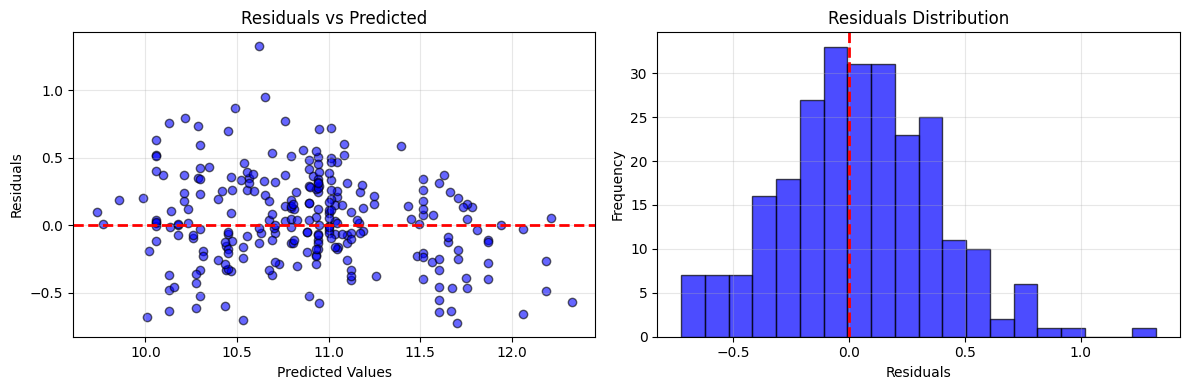

In [ ]:
print("3. ML View :")
ml_model = MultiLinearRegressionGD()
print("\n--- Training Model ---")
ml_model.fit(X_train_final, y_train, learning_rate=0.05, epochs=3000, verbose=True)
print("\n--- Coefficients ---")
print(f"  Bias (b) = {ml_model.bias:.6f}")
for i, w in enumerate(ml_model.weights):
    print(f"  Weight_{i} = {w:.6f}")

y_pred_ml_train = ml_model.predict(X_train_final)
y_pred_ml_test = ml_model.predict(X_test_final)
print("\n--- R Squared Scores ---")
r2_train_ml = ml_model.r2_score(X_train_final, y_train)
r2_test_ml = ml_model.r2_score(X_test_final, y_test)
print(f"  Train R Squared: {r2_train_ml:.6f}")
print(f"  Test R Squared:  {r2_test_ml:.6f}")
print("\n--- Loss History ---")
print(f"  Initial Loss: {ml_model.loss_history[0]:.6f}")
print(f"  Final Loss: {ml_model.loss_history[-1]:.6f}")
print(f"  Total Epochs: {len(ml_model.loss_history)}")
print("\n--- Loss Curve Plot ---")
fig_loss = ml_model.plot_loss_interactive()
fig_loss.show()
print("\n--- Residuals Plot ---")
ml_model.plot_residuals(X_test_final, y_test)


In [ ]:
fig_ml = plot_model_scatter(ml_model, X_test_final, y_test, "Multiple Linear Regression (GD)")
fig_ml.show()

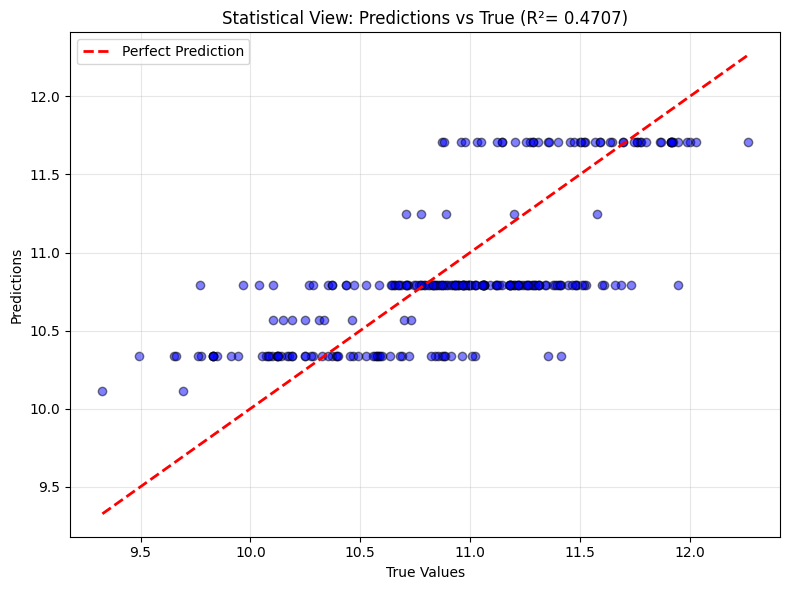

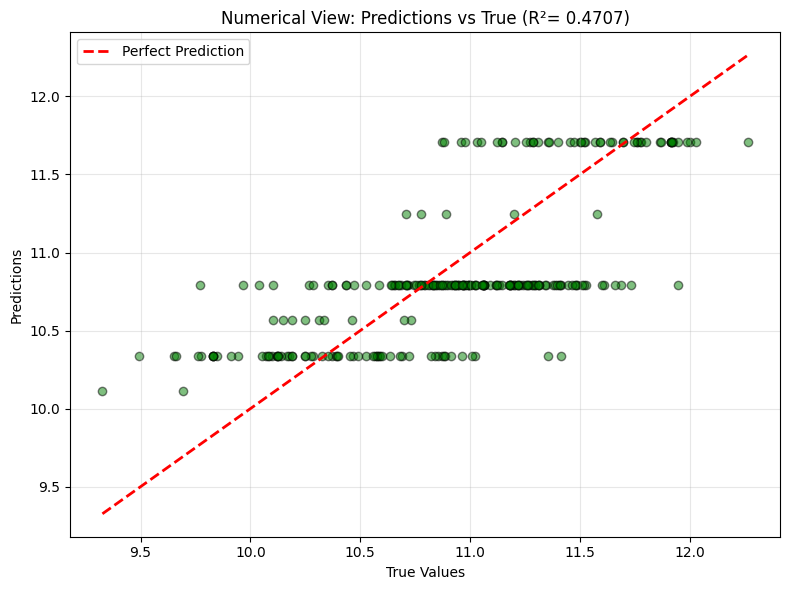

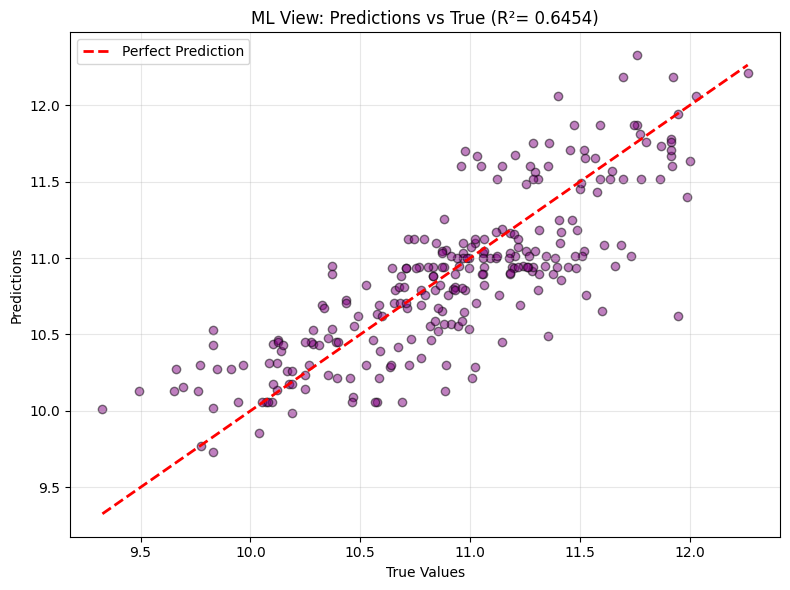

In [ ]:
# Statistical View
stat_model.plot_predictions_vs_true(X_test_final[:, 0], y_test.values)

# Numerical View
num_model.plot_predictions_vs_true(X_test_final[:, 0], y_test.values)

# ML View
ml_model.plot_predictions_vs_true(X_test_final, y_test.values)

In [ ]:
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1)) / (n - p - 1)


print(f"CASE 1: Best Single Predictor — {best_feature}")
print("=" * 60)

p = 1

print("\n[Statistical View]")

stat_plain = SimpleLinearRegressionStatistical()
stat_plain.fit(X_train_best.flatten(), y_train)
r2_train = stat_plain.r2_score(X_train_best.flatten(), y_train)
r2_test  = stat_plain.r2_score(X_test_best.flatten(), y_test)
print(f"Train R²: {r2_train:.4f} | Adj R²: {adjusted_r2(r2_train,len(y_train),p):.4f}")
print(f"Test  R²: {r2_test:.4f} | Adj R²: {adjusted_r2(r2_test,len(y_test),p):.4f}")


stat_lasso = SimpleLinearRegressionStatistical(lasso=0.1)
stat_lasso.fit(X_train_best.flatten(), y_train)
r2_train = stat_lasso.r2_score(X_train_best.flatten(), y_train)
r2_test  = stat_lasso.r2_score(X_test_best.flatten(), y_test)
print(f"\nTrain R² (Lasso): {r2_train:.4f} | Adj R²: {adjusted_r2(r2_train,len(y_train),p):.4f}")
print(f"Test  R²:         {r2_test:.4f} | Adj R²: {adjusted_r2(r2_test,len(y_test),p):.4f}")


stat_ridge = SimpleLinearRegressionStatistical(ridge=0.1)
stat_ridge.fit(X_train_best.flatten(), y_train)
r2_train = stat_ridge.r2_score(X_train_best.flatten(), y_train)
r2_test  = stat_ridge.r2_score(X_test_best.flatten(), y_test)
print(f"\nTrain R² (Ridge): {r2_train:.4f} | Adj R²: {adjusted_r2(r2_train,len(y_train),p):.4f}")
print(f"Test  R²:         {r2_test:.4f} | Adj R²: {adjusted_r2(r2_test,len(y_test),p):.4f}")



print("\n[Numerical View]")

num_plain = SimpleLinearRegressionNumerical()
num_plain.fit(X_train_best.flatten(), y_train, show_steps=False)
r2_train = num_plain.r2_score(X_train_best.flatten(), y_train)
r2_test  = num_plain.r2_score(X_test_best.flatten(), y_test)
print(f"Train R²: {r2_train:.4f} | Adj R²: {adjusted_r2(r2_train,len(y_train),p):.4f}")
print(f"Test  R²: {r2_test:.4f} | Adj R²: {adjusted_r2(r2_test,len(y_test),p):.4f}")


num_lasso = SimpleLinearRegressionNumerical(lasso=0.1)
num_lasso.fit(X_train_best.flatten(), y_train, show_steps=False)
r2_train = num_lasso.r2_score(X_train_best.flatten(), y_train)
r2_test  = num_lasso.r2_score(X_test_best.flatten(), y_test)
print(f"\nTrain R² (Lasso): {r2_train:.4f} | Adj R²: {adjusted_r2(r2_train,len(y_train),p):.4f}")
print(f"Test  R²:         {r2_test:.4f} | Adj R²: {adjusted_r2(r2_test,len(y_test),p):.4f}")


num_ridge = SimpleLinearRegressionNumerical(ridge=0.1)
num_ridge.fit(X_train_best.flatten(), y_train, show_steps=False)
r2_train = num_ridge.r2_score(X_train_best.flatten(), y_train)
r2_test  = num_ridge.r2_score(X_test_best.flatten(), y_test)
print(f"\nTrain R² (Ridge): {r2_train:.4f} | Adj R²: {adjusted_r2(r2_train,len(y_train),p):.4f}")
print(f"Test  R²:         {r2_test:.4f} | Adj R²: {adjusted_r2(r2_test,len(y_test),p):.4f}")


print("\n[ML View]")

ml_plain = MultiLinearRegressionGD()
ml_plain.fit(X_train_best, y_train, verbose=False)
r2_train = ml_plain.r2_score(X_train_best, y_train)
r2_test  = ml_plain.r2_score(X_test_best, y_test)
print(f"Train R²: {r2_train:.4f} | Adj R²: {adjusted_r2(r2_train,len(y_train),p):.4f}")
print(f"Test  R²: {r2_test:.4f} | Adj R²: {adjusted_r2(r2_test,len(y_test),p):.4f}")


ml_lasso = MultiLinearRegressionGD(lasso=0.1)
ml_lasso.fit(X_train_best, y_train, verbose=False)
r2_train = ml_lasso.r2_score(X_train_best, y_train)
r2_test  = ml_lasso.r2_score(X_test_best, y_test)
print(f"\nTrain R² (Lasso): {r2_train:.4f} | Adj R²: {adjusted_r2(r2_train,len(y_train),p):.4f}")
print(f"Test  R²:         {r2_test:.4f} | Adj R²: {adjusted_r2(r2_test,len(y_test),p):.4f}")


ml_ridge = MultiLinearRegressionGD(ridge=0.1)
ml_ridge.fit(X_train_best, y_train, verbose=False)
r2_train = ml_ridge.r2_score(X_train_best, y_train)
r2_test  = ml_ridge.r2_score(X_test_best, y_test)
print(f"\nTrain R² (Ridge): {r2_train:.4f} | Adj R²: {adjusted_r2(r2_train,len(y_train),p):.4f}")
print(f"Test  R²:         {r2_test:.4f} | Adj R²: {adjusted_r2(r2_test,len(y_test),p):.4f}")

models = {
    "Statistical": SimpleLinearRegressionStatistical,
    "Numerical": SimpleLinearRegressionNumerical,
    "ML": MultiLinearRegressionGD
}

configs = [
    ("Baseline", {}),
    ("Lasso", {"lasso": 0.1}),
    ("Ridge", {"ridge": 0.1})
]

X_train_flattened = X_train_best.flatten()
X_test_flattened = X_test_best.flatten()

for name, Model in models.items():
    print(f"\n[{name} View]")

    for cfg_name, params in configs:
        model = Model(**params)
        fit_kwargs = {}
        current_X_train_input = X_train_flattened
        current_X_test_input = X_test_flattened

        if name == "Numerical":
            fit_kwargs['show_steps'] = False
        elif name == "ML":
            fit_kwargs['verbose'] = False
            current_X_train_input = X_train_best  # ML model expects 2D array
            current_X_test_input = X_test_best    # ML model expects 2D array

        model.fit(current_X_train_input, y_train, **fit_kwargs)

        print(
            f"{cfg_name} → "
            f"Train R²: {model.r2_score(current_X_train_input, y_train):.4f} | "
            f"Test R²: {model.r2_score(current_X_test_input, y_test):.4f} || "
            f"Train Adj R²: {model.adjusted_r2_score(current_X_train_input, y_train):.4f} | "
            f"Test Adj R²: {model.adjusted_r2_score(current_X_test_input, y_test):.4f}"
        )



CASE 1: Best Single Predictor — Ram

[Statistical View]
Statistical View Results:
  B_0 (intercept) = 10.801756
  B_1 (slope)     = 0.459060
  MSE             = 0.186332
  Lasso (lambda)  = 0
  Ridge (lambda)  = 0
Train R²: 0.5310 | Adj R²: 0.5305
Test  R²: 0.4707 | Adj R²: 0.4687
Statistical View Results:
  B_0 (intercept) = 10.801756
  B_1 (slope)     = 0.459060
  MSE             = 0.232238
  Lasso (lambda)  = 0.1
  Ridge (lambda)  = 0

Train R² (Lasso): 0.5310 | Adj R²: 0.5305
Test  R²:         0.4707 | Adj R²: 0.4687
Statistical View Results:
  B_0 (intercept) = 10.801756
  B_1 (slope)     = 0.459060
  MSE             = 0.207406
  Lasso (lambda)  = 0
  Ridge (lambda)  = 0.1

Train R² (Ridge): 0.5310 | Adj R²: 0.5305
Test  R²:         0.4707 | Adj R²: 0.4687

[Numerical View]

Final Model: y = 10.801756 + 0.459060x
MSE (with regularization) = 0.186332
Lasso (lambda) = 0 | Ridge (lambda) = 0
Train R²: 0.5310 | Adj R²: 0.5305
Test  R²: 0.4707 | Adj R²: 0.4687

Final Model: y = 10.8017

CASE 2: Full Model — All Features

Base Model
Train R²: 0.7906 | Test R²: 0.7321
Train Adj R²: 0.7805 | Test Adj R²: 0.6719

Lasso Model
Train R²: 0.6703 | Test R²: 0.6280
Train Adj R²: 0.6544 | Test Adj R²: 0.5444

Ridge Model
Train R²: 0.7634 | Test R²: 0.7085
Train Adj R²: 0.7520 | Test Adj R²: 0.6429


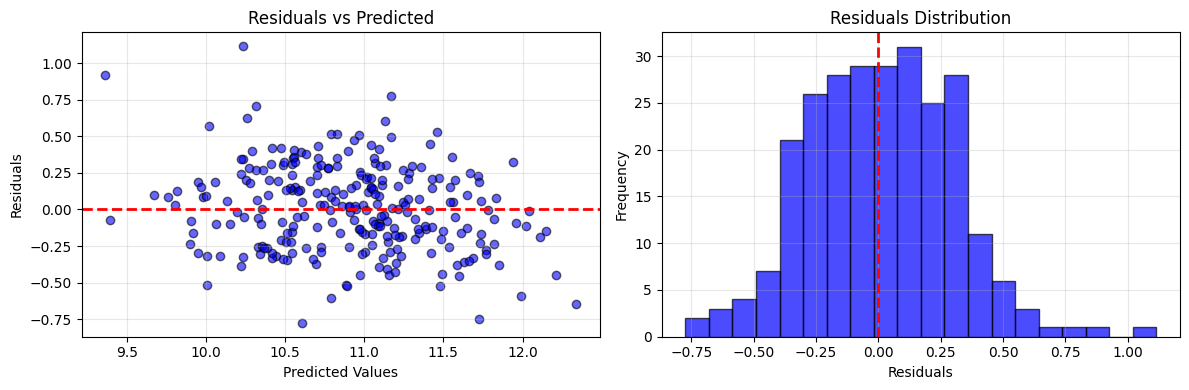

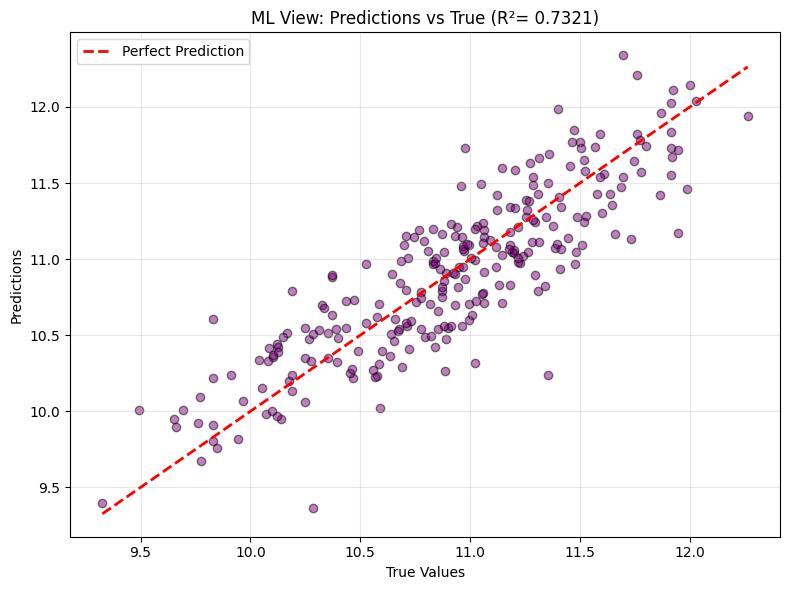

In [ ]:
print("CASE 2: Full Model — All Features")
print("=" * 60)

ml_full_plain = MultiLinearRegressionGD(lasso=0, ridge=0)
ml_full_plain.fit(X_train_full,y_train,learning_rate=0.05,epochs=3000,verbose=False)

ml_full_lasso = MultiLinearRegressionGD(lasso=0.1, ridge=0)
ml_full_lasso.fit(X_train_full,y_train,learning_rate=0.05,epochs=3000,verbose=False)


ml_full_ridge = MultiLinearRegressionGD(lasso=0, ridge=0.1)
ml_full_ridge.fit(X_train_full,y_train,learning_rate=0.05,epochs=3000, verbose=False)

models = {
    "Base": ml_full_plain,
    "Lasso": ml_full_lasso,
    "Ridge": ml_full_ridge
}

for name, model in models.items():
    train_r2 = model.r2_score(X_train_full, y_train)
    test_r2  = model.r2_score(X_test_full, y_test)

    train_adj = model.adjusted_r2_score(X_train_full, y_train)
    test_adj  = model.adjusted_r2_score(X_test_full, y_test)

    print(f"\n{name} Model")
    print(f"Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
    print(f"Train Adj R²: {train_adj:.4f} | Test Adj R²: {test_adj:.4f}")

ml_full_plain.plot_loss_interactive().show()
ml_full_plain.plot_residuals(X_test_full, y_test)
ml_full_plain.plot_predictions_vs_true(X_test_full, y_test)

# Case 3: Domain Knowledge Model
In this experiment, regression models (Base, Lasso, and Ridge) were trained using the top 5 features selected based on domain knowledge to reduce model complexity.

The Ridge model achieved the best test performance, indicating stronger generalization ability. The Base model exhibited slight overfitting, as reflected by the gap between training and testing scores. In contrast, Lasso showed lower performance, suggesting that its regularization may have been too aggressive, removing informative features.

CASE 3: Domain Knowledge Model

Base Model
Train R²: 0.7349 | Test R²: 0.6554
Train Adj R²: 0.7336 | Test Adj R²: 0.6485

Lasso Model
Train R²: 0.6675 | Test R²: 0.6330
Train Adj R²: 0.6659 | Test Adj R²: 0.6257

Ridge Model
Train R²: 0.7263 | Test R²: 0.6628
Train Adj R²: 0.7249 | Test Adj R²: 0.6561


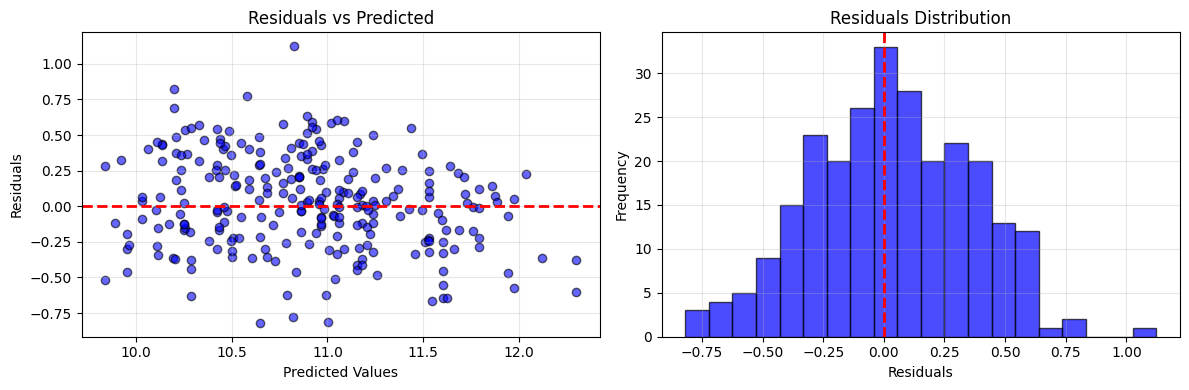

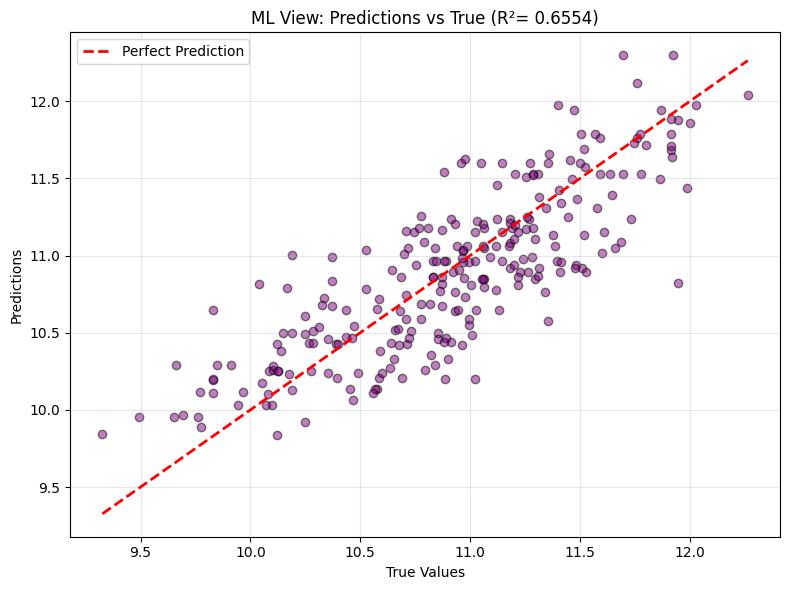

In [ ]:
print("CASE 3: Domain Knowledge Model")
print("=" * 60)


X_train_domain = X_train_all[top5].values.astype(float)
X_test_domain  = X_test_all[top5].values.astype(float)


ml_domain_plain = MultiLinearRegressionGD(lasso=0, ridge=0)
ml_domain_plain.fit(X_train_domain, y_train, learning_rate=0.5, epochs=3000, verbose=False)

ml_domain_lasso = MultiLinearRegressionGD(lasso=0.1, ridge=0)
ml_domain_lasso.fit(X_train_domain, y_train, learning_rate=0.5, epochs=3000, verbose=False)

ml_domain_ridge = MultiLinearRegressionGD(lasso=0, ridge=0.1)
ml_domain_ridge.fit(X_train_domain, y_train, learning_rate=0.5, epochs=3000, verbose=False)

models = {
    "Base": ml_domain_plain,
    "Lasso": ml_domain_lasso,
    "Ridge": ml_domain_ridge
}

for name, model in models.items():
    train_r2 = model.r2_score(X_train_domain, y_train)
    test_r2  = model.r2_score(X_test_domain, y_test)

    train_adj = model.adjusted_r2_score(X_train_domain, y_train)
    test_adj  = model.adjusted_r2_score(X_test_domain, y_test)

    print(f"\n{name} Model")
    print(f"Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
    print(f"Train Adj R²: {train_adj:.4f} | Test Adj R²: {test_adj:.4f}")

ml_domain_plain.plot_loss_interactive().show()
ml_domain_plain.plot_residuals(X_test_domain, y_test)
ml_domain_plain.plot_predictions_vs_true(X_test_domain, y_test)

# Model Comparison Visualization

To compare model performance across different feature sets, we created a summary data frame including R² and Adjusted R² for Base, Lasso, and Ridge models.

The data was then reshaped into a long format to enable flexible visualization. Two bar plots were generated:

Standard R² Comparison to evaluate overall predictive performance
Adjusted R² Comparison to account for model complexity

This visualization allows for a clear comparison between:

Different feature selection strategies (Best Predictor, Full Features, Domain Knowledge)
The impact of regularization techniques (Plain, Lasso, Ridge)

In [ ]:
import pandas as pd

compare_models = pd.DataFrame([
    {
        "Model": "Best Predictor",
        "Plain": ml_plain.r2_score(X_test_best, y_test),
        "Plain_Adj": ml_plain.adjusted_r2_score(X_test_best, y_test),
        "Lasso": ml_lasso.r2_score(X_test_best, y_test),
        "Lasso_Adj": ml_lasso.adjusted_r2_score(X_test_best, y_test),
        "Ridge": ml_ridge.r2_score(X_test_best, y_test),
        "Ridge_Adj": ml_ridge.adjusted_r2_score(X_test_best, y_test),
    },
    {
        "Model": "Full Features",
        "Plain": ml_full_plain.r2_score(X_test_full, y_test),
        "Plain_Adj": ml_full_plain.adjusted_r2_score(X_test_full, y_test),
        "Lasso": ml_full_lasso.r2_score(X_test_full, y_test),
        "Lasso_Adj": ml_full_lasso.adjusted_r2_score(X_test_full, y_test),
        "Ridge": ml_full_ridge.r2_score(X_test_full, y_test),
        "Ridge_Adj": ml_full_ridge.adjusted_r2_score(X_test_full, y_test),
    },
    {
        "Model": "Domain Knowledge",
        "Plain": ml_domain_plain.r2_score(X_test_domain, y_test),
        "Plain_Adj": ml_domain_plain.adjusted_r2_score(X_test_domain, y_test),
        "Lasso": ml_domain_lasso.r2_score(X_test_domain, y_test),
        "Lasso_Adj": ml_domain_lasso.adjusted_r2_score(X_test_domain, y_test),
        "Ridge": ml_domain_ridge.r2_score(X_test_domain, y_test),
        "Ridge_Adj": ml_domain_ridge.adjusted_r2_score(X_test_domain, y_test),
    }
])

In [ ]:
df_melted = compare_models.melt(
    id_vars="Model",

    value_vars=["Plain", "Plain_Adj", "Lasso", "Lasso_Adj", "Ridge", "Ridge_Adj"],
    var_name="Metric_Type",
    value_name="Score"
)

df_melted['Regularization'] = df_melted['Metric_Type'].apply(lambda x: x.split('_')[0])
df_melted['Metric'] = df_melted['Metric_Type'].apply(lambda x: 'Adjusted R2' if 'Adj' in x else 'R2')

In [ ]:
import plotly.express as px
df_r2 = df_melted[~df_melted['Metric_Type'].str.contains('Adj')]

fig1 = px.bar(
    df_r2,
    x="Model",
    y="Score",
    color="Metric_Type",
    barmode="group",
    title="Standard R-Squared Comparison",
    range_y=[0, 1]
)

fig1.show()

df_adj = df_melted[df_melted['Metric_Type'].str.contains('Adj')]

fig2 = px.bar(
    df_adj,
    x="Model",
    y="Score",
    color="Metric_Type",
    barmode="group",
    title="Adjusted R-Squared Comparison",
    range_y=[0, 1],
    color_discrete_sequence=px.colors.sequential.Viridis
)

fig2.show()

# Comparison Table
This table compares the performance of different model specifications (Best Predictor, Full Model, and Domain Knowledge) under various regularization techniques using Test R² and Adjusted R², along with the number of predictors.

# Key Insights
1.The Full Model achieves the highest performance but with high complexity.

2.The Domain Knowledge (Ridge) model offers a strong trade-off between accuracy and simplicity.

3.Lasso slightly reduces performance, while a single predictor is insufficient.

In [ ]:
print(f"Number of features in Best Predictor: {X_train_best.shape[1]}")
print(f"Number of features in Full Dataset:  {X_train_full.shape[1]}")
print(f"Number of features in Domain: {len(top5)}")

Number of features in Best Predictor: 1
Number of features in Full Dataset:  47
Number of features in Domain: 5


| Model Specification     | Regularization | Test R² | Test Adjusted R² |  Predictors |
|------------------------|---------------|--------:|-----------------:|-------------|
| Best Single Predictor  | None          | 0.4667  | 0.4647               | 1           |
| Best Single Predictor  | Lasso         | 0.4716  | 0.4695               | 1           |
| Best Single Predictor  | Ridge         | 0.4764  |    0.4743            | 1           |
| Full Model             | None          | 0.7321  | 0.6719           | 47         |
| Full Model             | Lasso         | 0.6280  | 0.5444           | 47         |
| Full Model             | Ridge         | 0.7085  | 0.6429           | 47        |
| Domain Knowledge Model | None          | 0.6554  | 0.6485           | Selected  (5)  |
| Domain Knowledge Model | Lasso         | 0.6330  | 0.6257           | Selected (5)   |
| Domain Knowledge Model | Ridge         | 0.6628  | 0.6561           | Selected (5)   |
**Note:**  
Selected features are: Ram, SSD, Ppi, ClockSpeed, Weight


In [ ]:
import plotly.graph_objects as go

def get_data(model_name):
    if model_name == 'Best Single Predictor':
        pred = num_plain.predict(X_test_best.flatten())
        res = y_test.values.flatten() - pred

    elif model_name == 'Full Model':
        pred = ml_full_plain.predict(X_test_full)
        res = y_test.values.flatten() - pred.flatten()

    elif model_name == 'Domain Knowledge Model':
        pred = ml_domain_plain.predict(X_test_domain)
        res = y_test.values.flatten() - pred.flatten()

    return pred, res

models = ['Best Single Predictor', 'Full Model', 'Domain Knowledge Model']

fig = go.Figure()

for i, m in enumerate(models):
    pred, res = get_data(m)
    fig.add_trace(go.Scatter(
        x=pred,
        y=res,
        mode='markers',
        name=m,
        visible=(i == 0)
    ))

fig.add_hline(y=0, line_dash="dash", line_color="red")

buttons = []
for i, m in enumerate(models):
    vis = [False] * len(models)
    vis[i] = True
    buttons.append(dict(
        label=m,
        method="update",
        args=[{"visible": vis},
              {"title": f"Residual Plot - {m}"}]
    ))

fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.15,
        y=1.15
    )],
    title="Residual Plot - Best Single Predictor",
    xaxis_title="Predicted Values",
    yaxis_title="Residuals",
    template="plotly_white"
)

fig.show()

In [ ]:
domain_features = top5
domain_weights = ml_domain_plain.weights

indices_in_full = [list(X_train_full.columns).index(ind) for ind in domain_features]
full_weights_subset = [ml_full_plain.weights[i] for i in indices_in_full]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=domain_features,
    y=full_weights_subset,
    name='Full Model',
    marker_color='skyblue'
))

fig.add_trace(go.Bar(
    x=domain_features,
    y=domain_weights,
    name='Domain Knowledge Model',
    marker_color='red'
))


fig.add_hline(y=0, line_color="black", line_width=1.5)


fig.update_layout(
    barmode='group',
    title="Comparison of Beta Coefficients Across Models",
    yaxis_title="Coefficient (Beta)",
    template="plotly_white",
    legend_title_text="Models"
)

fig.show()